In [1]:
import os
import re
import sys
import zarr
import time
import numpy as np
import xarray as xr
from glob import glob

In [2]:
from datetime import datetime, timedelta

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
fn_init_boundary = sorted(glob('/glade/campaign/ral/wsap/ksha/FE_Cases/2018010100/ICBC/*'))

In [5]:
fn_init = '/glade/campaign/ral/wsap/ksha/FE_Cases/2018010100/ICBC/FE_interp_17UTC.0'
ds_init = xr.open_dataset(fn_init)

fn_boundary = '/glade/campaign/ral/wsap/ksha/FE_Cases/2018010100/ICBC/FE_Bndys.0'
ds_boundary = xr.open_dataset(fn_boundary)

In [6]:
dt_strings = ['2018010100', '2018010400', '2018011200', '2018011300', '2018011400', '2018011500', '2018011800', '2018012000', '2018012200', '2018012400', '2018012600', '2018012800', '2018013100']
variable_collection = [
    'u', 'v', 'w', 'theta', 'rho', 'qv', 'TKE_0'
]

# ind_pick = [ 0,  4,  8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64]
ind_pick = [1, 4, 20, 40]

In [10]:
ind = 0

start = time.time()

base_str = dt_strings[ind]
base_date = datetime.strptime(base_str, '%Y%m%d%H')

# ========================================================== #
# Fasteddy time coordinates
start_time = base_date.replace(hour=12, minute=15)
end_time = base_date.replace(hour=13, minute=0)

step = timedelta(seconds=30) # <----------------------- 30 second per step
n_steps = int((end_time - start_time) / step) + 1
time_list = [start_time + i * step for i in range(n_steps)]

# ========================================================== #
# output file process

fn_all = glob(f'/glade/derecho/scratch/casali/DigitalTwin/InputData/{base_str}/output/*')
fn_all = sorted(fn_all, key=lambda x: int(x.split('.')[-1]))

ds_collect = []
for i_fn, fn in enumerate(fn_all):
    ds = xr.open_dataset(fn)
    ds = ds[variable_collection].isel(zIndex=ind_pick)
    ds = ds.assign_coords(time=("time", [np.datetime64(time_list[i_fn], 'ns')]))
    ds_collect.append(ds)

ds_all = xr.concat(ds_collect, 'time')

ds_all = ds_all.isel(yIndex=slice(151, -151, 1), xIndex=slice(152, -152, 1)) # 16*37

# ========================================================== #
# variable chunking
varnames = list(ds_all.keys())
# zarr encodings
dict_encoding = {}

chunk_size_3d = dict(chunks=(12, 592, 592))
chunk_size_4d = dict(chunks=(1, 9, 592, 592))

compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)

for i_var, var in enumerate(varnames):
    dict_encoding[var] = {'compressor': compress, **chunk_size_4d}

save_name = '/glade/derecho/scratch/ksha/FastEddy/FE_runs/experiment_{:02d}.zarr'.format(ind)
print(save_name)
ds_all.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)

end = time.time()
print(f"Elapsed time: {end - start:.3f} seconds")

In [26]:
xr.open_zarr('/glade/derecho/scratch/ksha/FastEddy/FE_runs/experiment_00.zarr')

<xarray.Dataset>
Dimensions:  (time: 90, zIndex: 9, yIndex: 592, xIndex: 592)
Coordinates:
  * time     (time) datetime64[ns] 2018-01-01T12:15:00 ... 2018-01-01T12:59:30
  * xIndex   (xIndex) int32 152 153 154 155 156 157 ... 738 739 740 741 742 743
  * yIndex   (yIndex) int32 151 152 153 154 155 156 ... 737 738 739 740 741 742
  * zIndex   (zIndex) int32 0 4 12 20 28 36 44 52 60
Data variables:
    TKE_0    (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 9, 592, 592), meta=np.ndarray>
    qv       (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 9, 592, 592), meta=np.ndarray>
    rho      (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 9, 592, 592), meta=np.ndarray>
    theta    (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 9, 592, 592), meta=np.ndarray>
    u        (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 9, 592, 592), meta=np.ndarray>
    v        (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 9, 592, 592), meta=np.ndarray>
    w        (time, zIndex, yIndex, xIndex) float32 dask.array<chunksize=(1, 9, 592, 592), meta=np.ndarray>
Attributes:
    NCO:                        netCDF Operators version 5.2.4 (Homepage = ht...
    history:                    Thu Feb  6 11:50:10 2025: ncap2 -A -s BH_Topo...
    history_of_appended_files:  Thu May 16 14:37:52 2024: Appended file /glad...

* each case begins at 12:00:00 PM noon local time
* fasteddy runs on 0.01 sec per step on ending time, 3000 steps per output.
* the run begins with the 90000-th step (15 minutes), then outputs on every 0.5 min up to 59.5 min, 89 steps in total per case with the last step missing
* 60 boundary steps, each step is a minute begin with 12:00:00 (0, 1, 2, ..., 60 min)

In [8]:
fn_outputs = sorted(glob('/glade/derecho/scratch/casali/DigitalTwin/InputData/2018010100/output/*'))

In [15]:
fn_output = '/glade/derecho/scratch/casali/DigitalTwin/InputData/2018010100/output/FE_downtown.105000'
ds_output = xr.open_dataset(fn_output)

In [15]:
Z = ds_output['zPos'].isel(time=0).values

In [33]:
ind_pick = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]

In [16]:
Z = ds_output['zPos'].isel(time=0).values

In [21]:
H = ds_output['BuildingHeights'].isel(time=0).values

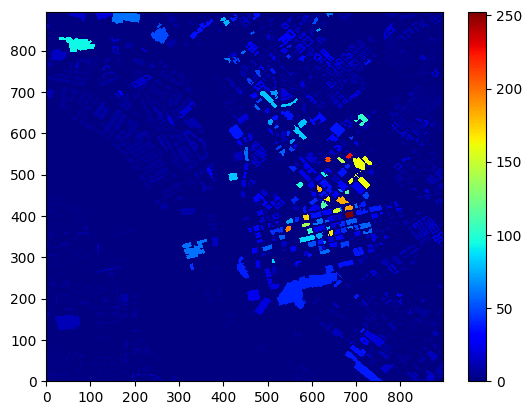

In [23]:
plt.pcolormesh(H, cmap=plt.cm.jet)
plt.colorbar()

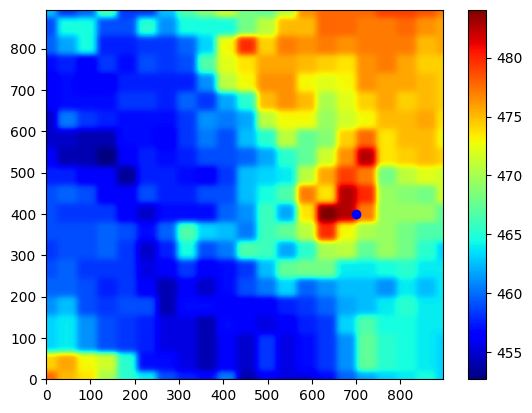

In [20]:
plt.pcolormesh(Z[60, ...], cmap=plt.cm.jet)
plt.plot(700, 400, 'bo')
plt.colorbar()

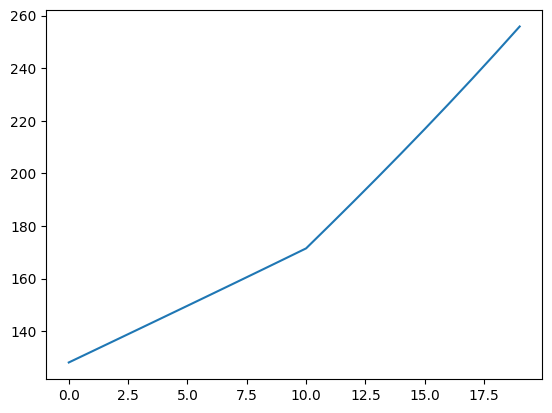

In [30]:
plt.plot(Z[ind_pick, 60, 400])